# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str, encoding='utf-8-sig')
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str, encoding='utf-8-sig')
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str, encoding='utf-8-sig')

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f'\n=== {nombre} === dims={df.shape}')
    print(list(df.columns))
    display(df.head(2))



=== 2018 === dims=(50, 16)
['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup



=== 2022 === dims=(51, 16)
['match_id', 'WorldCup', 'stage', 'group_name', 'match_day', 'date', 'local', 'visitor', 'home_score', 'away_score', 'score_text', 'home_host', 'venue', 'city_name', 'comentario', 'source_url']


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup



=== 2026 === dims=(75, 14)
['match', 'wc', 'round', 'grp', 'md', 'played_on', 'home', 'away', 'HG', 'AG', 'result_raw', 'host_h', 'host_a', 'source']


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'PERFIL: {nombre}')
    print(sep)
    print(f'Filas: {len(df)}  |  Columnas: {len(df.columns)}')
    print('\nColumnas:', list(df.columns))
    print('\nNulos por columna:')
    print(df.isnull().sum())
    print(f'\nDuplicados completos: {df.duplicated().sum()}')
    for col in df.columns:
        n_uniq = df[col].nunique(dropna=False)
        if n_uniq <= 15:
            print(f'  {col} -> {sorted(df[col].dropna().unique())}')

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')



PERFIL: 2018
Filas: 50  |  Columnas: 16

Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Duplicados completos: 2
  Año -> ['2018']
  Fase -> ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']
  Jornada -> ['1', '2', '3']
  Hora -> ['13:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00']
  Goles Local -> ['-1', '0', '1', '1 goles', '2', '3', '5 goles', '6']
  Goles Visitante -> ['0', '1', '2', '3']
  Anfitrión Local -> ['0', 'FA

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
        'ID Partido':           'partido_id',
        'A\u00f1o':            'mundial',
        'Fase':                 'fase',
        'Grupo':                'grupo',
        'Jornada':              'jornada',
        'Fecha':                'fecha',
        'Hora':                 'hora',
        'Equipo Local':         'equipo_local',
        'Equipo Visitante':     'equipo_visitante',
        'Goles Local':          'goles_local',
        'Goles Visitante':      'goles_visitante',
        'Marcador':             'marcador',
        'Anfitri\u00f3n Local':'local_es_anfitrion',
        'Estadio':              'estadio',
        'Ciudad':               'ciudad',
        'Fuente':               'fuente',
    },
    2022: {
        'match_id':   'partido_id',
        'WorldCup':   'mundial',
        'stage':      'fase',
        'group_name': 'grupo',
        'match_day':  'jornada',
        'date':       'fecha',
        'local':      'equipo_local',
        'visitor':    'equipo_visitante',
        'home_score': 'goles_local',
        'away_score': 'goles_visitante',
        'score_text': 'marcador',
        'home_host':  'local_es_anfitrion',
        'venue':      'estadio',
        'city_name':  'ciudad',
        'source_url': 'fuente',
    },
    2026: {
        'match':      'partido_id',
        'wc':         'mundial',
        'round':      'fase',
        'grp':        'grupo',
        'md':         'jornada',
        'played_on':  'fecha',
        'home':       'equipo_local',
        'away':       'equipo_visitante',
        'HG':         'goles_local',
        'AG':         'goles_visitante',
        'result_raw': 'marcador',
        'host_h':     'local_es_anfitrion',
        'host_a':     'visitante_es_anfitrion',
        'source':     'fuente',
    },
}

columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]
print('Esquema canonico:', columnas_base)


Esquema canonico: ['partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha', 'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'marcador', 'local_es_anfitrion', 'visitante_es_anfitrion', 'fuente']


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv', encoding='utf-8-sig')

def clave_texto(valor):
    if pd.isna(valor):
        return ''
    valor = str(valor).strip()
    nfkd = unicodedata.normalize('NFKD', valor)
    sin_acentos = ''.join(c for c in nfkd if not unicodedata.combining(c))
    limpio = re.sub(r'[^a-z0-9 ]', ' ', sin_acentos.lower())
    return re.sub(r'\s+', ' ', limpio).strip()

dict_canonico = {
    clave_texto(row['variante']): row['nombre_canonico']
    for _, row in catalogo.iterrows()
}

def canonizar_equipo(nombre):
    k = clave_texto(nombre)
    return dict_canonico.get(k, nombre.strip() if isinstance(nombre, str) else nombre)

print(f'Catalogo cargado: {len(catalogo)} variantes')
print('Columnas:', list(catalogo.columns))
print('Prueba USA:', canonizar_equipo('USA'))
print('Prueba russia:', canonizar_equipo('russia'))


Catalogo cargado: 95 variantes
Columnas: ['variante', 'nombre_canonico', 'codigo']
Prueba USA: United States
Prueba russia: Russia


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}
FORMATOS_FECHA = [
    '%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y',
    '%d-%m-%y', '%d-%m-%Y', '%Y/%m/%d',
]
ORIGEN_EXCEL = pd.Timestamp('1899-12-30')

def convertir_fecha(valor, mundial):
    if pd.isna(valor) or str(valor).strip() == '':
        return pd.NaT
    s = str(valor).strip()
    rng_ini = pd.Timestamp(rangos[mundial][0])
    rng_fin = pd.Timestamp(rangos[mundial][1])
    try:
        ts = ORIGEN_EXCEL + pd.Timedelta(days=float(s))
        if rng_ini <= ts <= rng_fin:
            return ts
    except (ValueError, OverflowError):
        pass
    for fmt in FORMATOS_FECHA:
        try:
            ts = pd.Timestamp(pd.to_datetime(s, format=fmt))
            if rng_ini <= ts <= rng_fin:
                return ts
        except Exception:
            continue
    try:
        ts = pd.Timestamp(pd.to_datetime(s, dayfirst=True))
        if rng_ini <= ts <= rng_fin:
            return ts
    except Exception:
        pass
    return pd.NaT

def extraer_numero(valor):
    if pd.isna(valor):
        return np.nan
    m = re.search(r'-?\d+', str(valor))
    if m:
        n = int(m.group())
        return float(n) if n >= 0 else np.nan
    return np.nan

def separar_marcador(valor):
    if pd.isna(valor) or str(valor).strip() == '':
        return np.nan, np.nan
    s = re.sub(r'[\u2013\u2014]', '-', str(valor))
    m = re.search(r'(\d+)\s*[-:xX]\s*(\d+)', s)
    if m:
        return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan

def normalizar_grupo(valor):
    if pd.isna(valor):
        return np.nan
    m = re.search(r'[A-La-l]', str(valor))
    return m.group().upper() if m else np.nan

VERDADEROS = {'si', 's', '1', 'true', 'yes', 'y', '1.0'}

def normalizar_booleano(valor):
    if pd.isna(valor):
        return False
    return clave_texto(str(valor)) in VERDADEROS

print('Funciones definidas OK')
print('separar_marcador("3 x 3"):', separar_marcador('3 x 3'))
print('normalizar_grupo("Grupo A"):', normalizar_grupo('Grupo A'))
print('normalizar_booleano("Si"):', normalizar_booleano('Si'))


Funciones definidas OK
separar_marcador("3 x 3"): (3.0, 3.0)
normalizar_grupo("Grupo A"): G
normalizar_booleano("Si"): True


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df, mundial):
    df = df.copy()
    rmap = {k: v for k, v in rename_maps[mundial].items() if k in df.columns}
    df.rename(columns=rmap, inplace=True)
    for col in columnas_base:
        if col not in df.columns:
            df[col] = np.nan
    df['mundial'] = mundial
    df['equipo_local']     = df['equipo_local'].apply(canonizar_equipo)
    df['equipo_visitante'] = df['equipo_visitante'].apply(canonizar_equipo)
    df['grupo']   = df['grupo'].apply(normalizar_grupo)
    df['fecha']   = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
    df['jornada'] = df['jornada'].apply(extraer_numero)
    df['local_es_anfitrion']     = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)

    marc_split = df['marcador'].apply(separar_marcador)
    df['_gl_m'] = marc_split.apply(lambda t: t[0])
    df['_gv_m'] = marc_split.apply(lambda t: t[1])
    df['goles_local']     = df['goles_local'].apply(extraer_numero)
    df['goles_visitante'] = df['goles_visitante'].apply(extraer_numero)

    def reparar(gl, gv, ml, mv):
        if not pd.isna(gl) and gl >= 0 and not pd.isna(gv) and gv >= 0:
            return gl, gv
        if not pd.isna(ml) and not pd.isna(mv):
            return ml, mv
        return np.nan, np.nan

    rep = df.apply(lambda r: reparar(r['goles_local'], r['goles_visitante'],
                                      r['_gl_m'], r['_gv_m']), axis=1)
    df['goles_local']     = rep.apply(lambda t: t[0])
    df['goles_visitante'] = rep.apply(lambda t: t[1])
    df.drop(columns=['_gl_m', '_gv_m'], inplace=True)

    def fmt_marc(r):
        if not pd.isna(r['goles_local']) and not pd.isna(r['goles_visitante']):
            return f"{int(r['goles_local'])}-{int(r['goles_visitante'])}"
        return np.nan
    df['marcador'] = df.apply(fmt_marc, axis=1)

    eq_g = (df.dropna(subset=['grupo'])
              .melt(id_vars='grupo', value_vars=['equipo_local','equipo_visitante'], value_name='equipo')
              .drop_duplicates('equipo').set_index('equipo')['grupo'].to_dict())
    mask = df['grupo'].isna()
    df.loc[mask, 'grupo'] = df.loc[mask, 'equipo_local'].map(eq_g)

    df.drop_duplicates(subset=['partido_id'], keep='first', inplace=True)

    df['goles_totales']    = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']

    def resultado(row):
        if pd.isna(row['goles_local']) or pd.isna(row['goles_visitante']):
            return np.nan
        if row['goles_local'] > row['goles_visitante']:   return 'Gana'
        elif row['goles_local'] < row['goles_visitante']: return 'Pierde'
        return 'Empata'

    df['resultado_local'] = df.apply(resultado, axis=1)
    cols_extra = ['goles_totales','diferencia_goles','resultado_local']
    df = df[[c for c in columnas_base + cols_extra if c in df.columns]]
    return df.reset_index(drop=True)

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
print(f'Total: {len(partidos)} | 2018:{len(limpio18)} 2022:{len(limpio22)} 2026:{len(limpio26)}')
display(partidos.head())


Total: 168 | 2018:48 2022:48 2026:72


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente,goles_totales,diferencia_goles,resultado_local
0,M-2018-01,2018,Fase de grupos,G,1.0,2018-06-14,Russia,Saudi Arabia,5.0,0.0,5-0,True,False,https://github.com/jfjelstul/worldcup,5.0,5.0,Gana
1,M-2018-02,2018,GROUP STAGE,A,1.0,2018-06-15,Egypt,Uruguay,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,1.0,-1.0,Pierde
2,M-2018-03,2018,grupos,G,1.0,2018-06-15,Morocco,Iran,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,1.0,-1.0,Pierde
3,M-2018-04,2018,1ra fase,G,1.0,2018-06-15,Portugal,Spain,3.0,3.0,3-3,False,False,https://github.com/jfjelstul/worldcup,6.0,0.0,Empata
4,M-2018-05,2018,Fase de grupos,C,1.0,2018-06-16,France,Australia,2.0,1.0,2-1,False,False,https://github.com/jfjelstul/worldcup,3.0,1.0,Gana


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
errores = []
conteos = partidos['mundial'].value_counts().sort_index()
for anio, exp in {2018:48, 2022:48, 2026:72}.items():
    real = int(conteos.get(anio, 0))
    ok = 'OK' if real == exp else f'ERROR (esperado {exp})'
    print(f'  Partidos {anio}: {real}  [{ok}]')
    if real != exp: errores.append(f'{anio}: {real}!={exp}')

dups = partidos.duplicated(subset=['partido_id']).sum()
print(f'  Duplicados: {dups}  [{"OK" if dups==0 else "ERROR"}]')
if dups: errores.append(f'{dups} duplicados')

neg = ((partidos['goles_local']<0)|(partidos['goles_visitante']<0)).sum()
print(f'  Goles negativos: {neg}  [{"OK" if neg==0 else "ERROR"}]')
if neg: errores.append(f'{neg} goles negativos')

for col in ['equipo_local','equipo_visitante','goles_local','goles_visitante','grupo']:
    n = partidos[col].isna().sum()
    print(f'  Nulos en {col}: {n}  [{"OK" if n==0 else "REVISAR"}]')

if errores:
    print('\nProblemas:', errores)
else:
    print('\nTodas las validaciones pasaron.')


  Partidos 2018: 48  [OK]
  Partidos 2022: 48  [OK]
  Partidos 2026: 72  [OK]
  Duplicados: 0  [OK]
  Goles negativos: 0  [OK]
  Nulos en equipo_local: 0  [OK]
  Nulos en equipo_visitante: 0  [OK]
  Nulos en goles_local: 0  [OK]
  Nulos en goles_visitante: 0  [OK]
  Nulos en grupo: 0  [OK]

Todas las validaciones pasaron.


## Comparación de los Mundiales

,mundial,partidos,goles,empates,goles_por_partido,pct_empates
0,2018,48,122.0,9,2.541667,18.750000
1,2022,48,120.0,10,2.500000,20.833333
2,2026,72,215.0,20,2.986111,27.777778


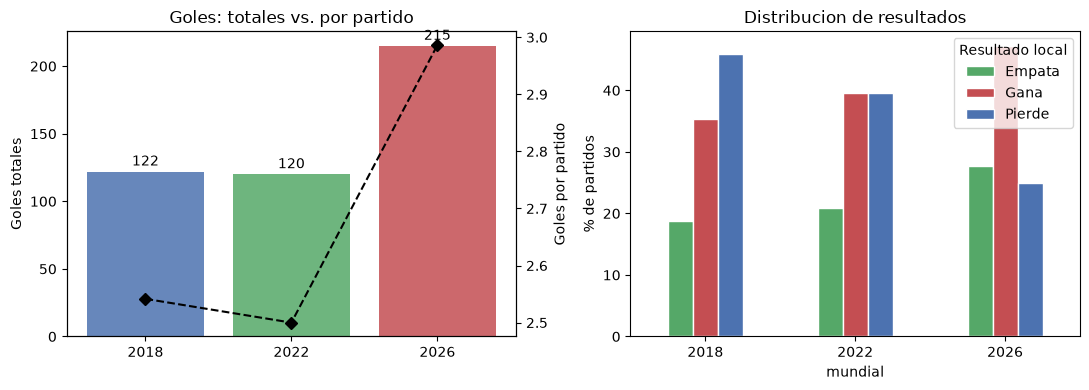

In [9]:
resumen = partidos.groupby('mundial').agg(
    partidos=('partido_id','count'),
    goles=('goles_totales','sum'),
    empates=('resultado_local', lambda s: (s=='Empata').sum()),
).reset_index()
resumen['goles_por_partido']  = resumen['goles'] / resumen['partidos']
resumen['pct_empates']        = resumen['empates'] / resumen['partidos'] * 100
display(resumen)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = ['#4C72B0','#55A868','#C44E52']
x = list(range(len(resumen)))
labels = resumen['mundial'].astype(str).tolist()

ax1 = axes[0]
bars = ax1.bar(x, resumen['goles'], color=colores, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Goles totales'); ax1.set_title('Goles: totales vs. por partido')
ax1.bar_label(bars, fmt='%d', padding=2)
ax2 = ax1.twinx()
ax2.plot(x, resumen['goles_por_partido'], 'D--', color='black')
ax2.set_ylabel('Goles por partido')

ax3 = axes[1]
rp = (partidos.groupby(['mundial','resultado_local']).size()
              .unstack(fill_value=0)
              .div(resumen.set_index('mundial')['partidos'], axis=0)*100)
rp.plot(kind='bar', ax=ax3, color=['#55A868','#C44E52','#4C72B0'],
        edgecolor='white', rot=0)
ax3.set_ylabel('% de partidos'); ax3.set_title('Distribucion de resultados')
ax3.legend(title='Resultado local')
plt.tight_layout(); plt.show()


## Tabla por equipo

In [10]:
def tabla_equipos(df):
    loc = df[['mundial','equipo_local','goles_local','goles_visitante','resultado_local']].copy()
    loc.columns = ['mundial','equipo','GF','GC','resultado']
    vis = df[['mundial','equipo_visitante','goles_visitante','goles_local','resultado_local']].copy()
    vis['resultado'] = vis['resultado_local'].map({'Gana':'Pierde','Pierde':'Gana','Empata':'Empata'})
    vis = vis[['mundial','equipo_visitante','goles_visitante','goles_local','resultado']].copy()
    vis.columns = ['mundial','equipo','GF','GC','resultado']
    ap = pd.concat([loc, vis], ignore_index=True)
    ap['PJ']  = 1
    ap['PG']  = (ap['resultado']=='Gana').astype(int)
    ap['PE']  = (ap['resultado']=='Empata').astype(int)
    ap['PP']  = (ap['resultado']=='Pierde').astype(int)
    ap['PTS'] = ap['PG']*3 + ap['PE']
    tab = (ap.groupby(['mundial','equipo'])
             .agg(PJ=('PJ','sum'),PG=('PG','sum'),PE=('PE','sum'),
                  PP=('PP','sum'),GF=('GF','sum'),GC=('GC','sum'),PTS=('PTS','sum'))
             .reset_index())
    tab['DG']     = tab['GF'] - tab['GC']
    tab['PTS_PP'] = tab['PTS'] / tab['PJ']
    return tab.sort_values(['mundial','PTS','DG'], ascending=[True,False,False])

tabla = tabla_equipos(partidos)
print('Top 5 por puntos:')
display(tabla.nlargest(5,'PTS'))


Top 5 por puntos:


,mundial,equipo,PJ,PG,PE,PP,GF,GC,PTS,DG,PTS_PP
2,2018,Belgium,3,3,0,0,9.0,2.0,9,7.0,3.0
6,2018,Croatia,3,3,0,0,7.0,1.0,9,6.0,3.0
31,2018,Uruguay,3,3,0,0,5.0,0.0,9,5.0,3.0
81,2026,France,3,3,0,0,10.0,2.0,9,8.0,3.0
65,2026,Argentina,3,3,0,0,8.0,1.0,9,7.0,3.0


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos):
    registros = []
    for mundial, grp in partidos.groupby('mundial'):
        grp = grp.sort_values('fecha').reset_index(drop=True)
        estado = {}
        for _, row in grp.iterrows():
            loc = row['equipo_local']
            vis = row['equipo_visitante']
            for eq in (loc, vis):
                if eq not in estado:
                    estado[eq] = {'PJ':0,'PTS':0,'GF':0,'GC':0}
            def prom(eq, campo):
                e = estado[eq]
                return e[campo]/e['PJ'] if e['PJ']>0 else np.nan
            def prom_gd(eq):
                e = estado[eq]
                return (e['GF']-e['GC'])/e['PJ'] if e['PJ']>0 else np.nan
            registros.append({
                'partido_id':             row['partido_id'],
                'mundial':                mundial,
                'fecha':                  row['fecha'],
                'jornada':                row['jornada'],
                'equipo_local':           loc,
                'equipo_visitante':       vis,
                'local_es_anfitrion':     row['local_es_anfitrion'],
                'visitante_es_anfitrion': row['visitante_es_anfitrion'],
                'goles_local':            row['goles_local'],
                'goles_visitante':        row['goles_visitante'],
                'diferencia_goles':       row['diferencia_goles'],
                'resultado_local':        row['resultado_local'],
                'local_pts_prom_pre':     prom(loc,'PTS'),
                'local_gf_prom_pre':      prom(loc,'GF'),
                'local_gd_prom_pre':      prom_gd(loc),
                'visita_pts_prom_pre':    prom(vis,'PTS'),
                'visita_gf_prom_pre':     prom(vis,'GF'),
                'visita_gd_prom_pre':     prom_gd(vis),
            })
            gl, gv = row['goles_local'], row['goles_visitante']
            if not pd.isna(gl) and not pd.isna(gv):
                pts_l = 3 if gl>gv else (1 if gl==gv else 0)
                pts_v = 3 if gv>gl else (1 if gl==gv else 0)
                estado[loc]['PJ']+=1; estado[loc]['PTS']+=pts_l
                estado[loc]['GF']+=gl; estado[loc]['GC']+=gv
                estado[vis]['PJ']+=1; estado[vis]['PTS']+=pts_v
                estado[vis]['GF']+=gv; estado[vis]['GC']+=gl
    return pd.DataFrame(registros)

features_df = construir_variables_previas(partidos)
print(f'features_df: {features_df.shape}')
display(features_df.head())


features_df: (168, 18)


,partido_id,mundial,fecha,jornada,equipo_local,equipo_visitante,local_es_anfitrion,visitante_es_anfitrion,goles_local,goles_visitante,diferencia_goles,resultado_local,local_pts_prom_pre,local_gf_prom_pre,local_gd_prom_pre,visita_pts_prom_pre,visita_gf_prom_pre,visita_gd_prom_pre
0,M-2018-01,2018,2018-06-14,1.0,Russia,Saudi Arabia,True,False,5.0,0.0,5.0,Gana,NaN,NaN,NaN,NaN,NaN,NaN
1,M-2018-02,2018,2018-06-15,1.0,Egypt,Uruguay,False,False,0.0,1.0,-1.0,Pierde,NaN,NaN,NaN,NaN,NaN,NaN
2,M-2018-03,2018,2018-06-15,1.0,Morocco,Iran,False,False,0.0,1.0,-1.0,Pierde,NaN,NaN,NaN,NaN,NaN,NaN
3,M-2018-04,2018,2018-06-15,1.0,Portugal,Spain,False,False,3.0,3.0,0.0,Empata,NaN,NaN,NaN,NaN,NaN,NaN
4,M-2018-05,2018,2018-06-16,1.0,France,Australia,False,False,2.0,1.0,1.0,Gana,NaN,NaN,NaN,NaN,NaN,NaN


## Entrenamiento y prueba

Linea base ('Pierde'): 25.00%
Train: 96 partidos | Test: 72 partidos
Accuracy arbol: 45.83%


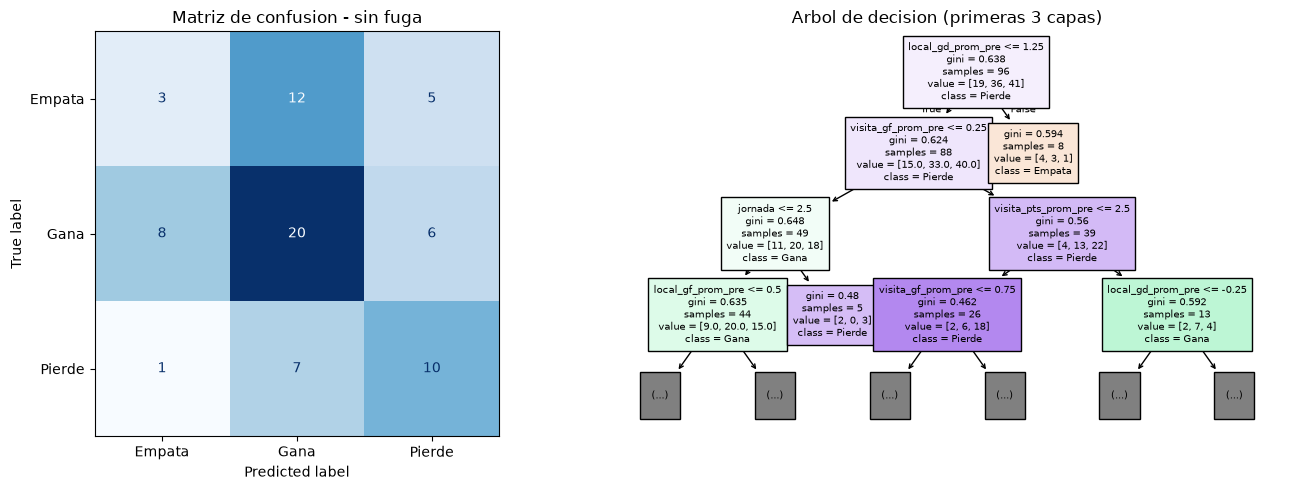

In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre',  'visita_gd_prom_pre',
    'local_gf_prom_pre',  'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

# Separar entrenamiento (2018+2022) y prueba (2026)
train_df = features_df[features_df['mundial'].isin([2018, 2022])].copy()
test_df  = features_df[features_df['mundial'] == 2026].copy()

# Eliminar filas sin etiqueta (resultado_local NaN = goles no disponibles)
train_df = train_df.dropna(subset=['resultado_local'])
test_df  = test_df.dropna(subset=['resultado_local'])

train_df[features] = train_df[features].fillna(0)
test_df[features]  = test_df[features].fillna(0)

for col in ['local_es_anfitrion', 'visitante_es_anfitrion']:
    train_df[col] = train_df[col].astype(int)
    test_df[col]  = test_df[col].astype(int)

X_train, y_train = train_df[features], train_df['resultado_local']
X_test,  y_test  = test_df[features],  test_df['resultado_local']

clase_mas_freq = y_train.mode()[0]
baseline_acc   = (y_test == clase_mas_freq).mean()
print(f'Linea base ({clase_mas_freq!r}): {baseline_acc:.2%}')
print(f'Train: {len(X_train)} partidos | Test: {len(X_test)} partidos')

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy arbol: {acc:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, ax=axes[0],
    display_labels=clf.classes_, colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusion - sin fuga')
plot_tree(clf, feature_names=features, class_names=clf.classes_,
          filled=True, ax=axes[1], fontsize=7, max_depth=3)
axes[1].set_title('Arbol de decision (primeras 3 capas)')
plt.tight_layout()
plt.show()


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [13]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']
X_train_f = train_df[features_fuga].fillna(0)
X_test_f  = test_df[features_fuga].fillna(0)

clf_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_fuga.fit(X_train_f, y_train)
acc_fuga = accuracy_score(y_test, clf_fuga.predict(X_test_f))

print(f'Accuracy SIN fuga : {acc:.2%}')
print(f'Accuracy CON fuga : {acc_fuga:.2%}')
print()
print('Explicacion: goles_local, goles_visitante y diferencia_goles son el')
print('RESULTADO del partido, no informacion disponible antes de jugarlo.')
print('El modelo los usa para reconocer el resultado directamente -> 100% inutil.')


Accuracy SIN fuga : 45.83%
Accuracy CON fuga : 100.00%

Explicacion: goles_local, goles_visitante y diferencia_goles son el
RESULTADO del partido, no informacion disponible antes de jugarlo.
El modelo los usa para reconocer el resultado directamente -> 100% inutil.


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
- El carácter invisible Byte Order Mark en la codificación de los archivos CSV (como variante o ID Partido). Que cuando los  leeiamos sin el               encoding adecuado (utf-8-sig), rompía los cruces y las funciones de renombrado de columnas, causando muchos KeyErrors.
- 
- ¿Qué decisión de limpieza podría cambiar los resultados?
- La regla de exclusión de partidos con datos faltantes (como los partidos sin marcador definido del 2026 s/d). Decidir si imputar los goles (usando       promedios) o eliminar las filas completas cambia la cantidad de registros disponibles y altera los promedios previos acumulados de cada selección.
- 
- ¿Por qué 2026 debe compararse mediante tasas?
- Porque el formato del Mundial cambió: 2026 tuvo 72 partidos de fase de grupos (48 equipos), mientras que 2018 y 2022 tuvieron 48 partidos (32            equipos). Comparar goles totales daría una falsa impresión de mayor ofensiva en 2026 simplemente porque se jugaron más partidos. Las tasas (por          partido) hacen la comparación justa.
- 
- ¿El árbol supera la línea base?
- Sí. La línea base (clasificar siempre con la clase más frecuente: 'Pierde') obtuvo un 25.00% de precisión, mientras que el Árbol de Decisión entrenado   alcanzó un 45.83% en el conjunto de prueba (2026).
- 
- ¿Qué variables reales agregarías para mejorar una predicción?
- El Ranking FIFA oficial de cada selección antes de iniciar el torneo.
- El valor de mercado o calidad de la plantilla.
- Historial de enfrentamientos directos (head-to-head).
- Bajas o lesiones de jugadores estrella antes del encuentro.
- 
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?
- Porque indica fuga de información (data leakage). Significa que le estamos dando al modelo variables explicativas que ocurren durante o después del partido (como los goles del partido actual o la diferencia de goles finales), lo cual hace que el modelo "adivine" el resultado en lugar de predecirlo con datos históricos previos.
- 